# Stage A — Data Definition

**What this notebook demonstrates:** reads the small tutorial subset (10 Earth models,
1 per family, both station geometries — 20 total samples), regrids the raw empirical
FTAN image onto the canonical (76, 300) grid, builds the training mask from the
theoretical dispersion curve, and shows the family-aware train/val/test split.

Runs in under a minute on a laptop CPU — no HPC/SSH access needed. Full findings and
verification detail (including a real QA-gate finding about FTAN cross-method
agreement): [../../../docs/ml_pipeline_stages/stage_a_data_definition.md](../../../docs/ml_pipeline_stages/stage_a_data_definition.md)


## 1. Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "CLAUDE.md").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import csv
import importlib

import matplotlib.pyplot as plt
import numpy as np

ftan_grid = importlib.import_module("src.wavenet_pipeline.03_machine_learning.ftan_grid")
dataset_mod = importlib.import_module("src.wavenet_pipeline.03_machine_learning.dataset")
splits_mod = importlib.import_module("src.wavenet_pipeline.03_machine_learning.splits")

DATA_DIR = REPO_ROOT / "src/wavenet_pipeline/03_machine_learning/data_samples"
H5_PATHS = [DATA_DIR / "tutorial_subset_sep127km.h5", DATA_DIR / "tutorial_subset_sep100km.h5"]

with open(DATA_DIR / "tutorial_manifest.csv") as f:
    manifest = list(csv.DictReader(f))
print(f"{len(manifest)} Earth models in the tutorial manifest (1 per family):")
for row in manifest:
    print(f"  {row['sim_key']}  (family {row['family']})")


Matplotlib is building the font cache; this may take a moment.


10 Earth models in the tutorial manifest (1 per family):
  M01_0776  (family M01)
  M02_0606  (family M02)
  M03_0385  (family M03)
  M04_0848  (family M04)
  M05_0690  (family M05)
  M06_0437  (family M06)
  M07_0210  (family M07)
  M08_0200  (family M08)
  M09_0158  (family M09)
  M10_0141  (family M10)


## 2. Enumerate samples

A **sample** is one (model, geometry) pair — not one model. With 2 station-separation
files and 10 models, we expect up to 20 samples (some models may be missing a geometry
in one file, but not in this tutorial subset).

In [2]:
samples = dataset_mod.enumerate_samples(H5_PATHS)
print(f"{len(samples)} samples found across {len({s.family for s in samples})} families")
for s in samples[:4]:
    print(" ", s)


20 samples found across 10 families
  SampleRef(h5_path=PosixPath('/Users/urseismoadmin/wavenet-epicAI/src/wavenet_pipeline/03_machine_learning/data_samples/tutorial_subset_sep127km.h5'), sim_key='M01_0776', geom_key='separation_127.0km', sep_km=127.0, family='M01')
  SampleRef(h5_path=PosixPath('/Users/urseismoadmin/wavenet-epicAI/src/wavenet_pipeline/03_machine_learning/data_samples/tutorial_subset_sep127km.h5'), sim_key='M02_0606', geom_key='separation_127.0km', sep_km=127.0, family='M02')
  SampleRef(h5_path=PosixPath('/Users/urseismoadmin/wavenet-epicAI/src/wavenet_pipeline/03_machine_learning/data_samples/tutorial_subset_sep127km.h5'), sim_key='M03_0385', geom_key='separation_127.0km', sep_km=127.0, family='M03')
  SampleRef(h5_path=PosixPath('/Users/urseismoadmin/wavenet-epicAI/src/wavenet_pipeline/03_machine_learning/data_samples/tutorial_subset_sep127km.h5'), sim_key='M04_0848', geom_key='separation_127.0km', sep_km=127.0, family='M04')


## 3. The canonical grid — a decision already made, not derived here

Two incompatible grid conventions exist in this project's history. This pipeline uses:
period **1-20s** (76 bins, 0.25s step) x group velocity **2-5 km/s** (300 bins),
padded to (80, 300). This matches `chrisScripts`' prototype and (not a coincidence —
see the module docstring) the exact grid `verify_main.py` already uses for its own
independent FTAN recompute.

In [3]:
print("PERIOD_GRID:", ftan_grid.PERIOD_GRID.shape, ftan_grid.PERIOD_GRID[:3], "...", ftan_grid.PERIOD_GRID[-3:])
print("VEL_GRID:   ", ftan_grid.VEL_GRID.shape, ftan_grid.VEL_GRID[:3], "...", ftan_grid.VEL_GRID[-3:])
print("Canonical padded shape:", (ftan_grid.PERIOD_BINS + ftan_grid.PAD_ROWS, ftan_grid.VEL_BINS))


PERIOD_GRID: (76,) [1.   1.25 1.5 ] ... [19.25 19.5  19.75]
VEL_GRID:    (300,) [2.   2.01 2.02] ... [4.97 4.98 4.99]
Canonical padded shape: (80, 300)


## 4. Regrid FTAN + build the target mask for a few samples

In [4]:
ds = dataset_mod.FTANDispersionDataset(samples)

preview = []
seen_families = set()
for i in range(len(ds)):
    if samples[i].family in seen_families:
        continue
    seen_families.add(samples[i].family)
    x, y, meta = ds[i]
    preview.append((x.squeeze(0).numpy(), y.squeeze(0).numpy(), meta))
    if len(preview) >= 4:
        break

for x, y, meta in preview:
    print(f"{meta['sim_key']} / {meta['geom_key']}: input {x.shape} range=[{x.min():.3f},{x.max():.3f}], "
          f"mask {y.shape} positive_frac={y[:76].mean():.4f}")


M01_0776 / separation_127.0km: input (80, 300) range=[0.000,1.000], mask (80, 300) positive_frac=0.0167
M02_0606 / separation_127.0km: input (80, 300) range=[0.000,1.000], mask (80, 300) positive_frac=0.0167
M03_0385 / separation_127.0km: input (80, 300) range=[0.000,1.000], mask (80, 300) positive_frac=0.0167
M04_0848 / separation_127.0km: input (80, 300) range=[0.000,1.000], mask (80, 300) positive_frac=0.0167


## 5. Visualize: FTAN image + mask overlay

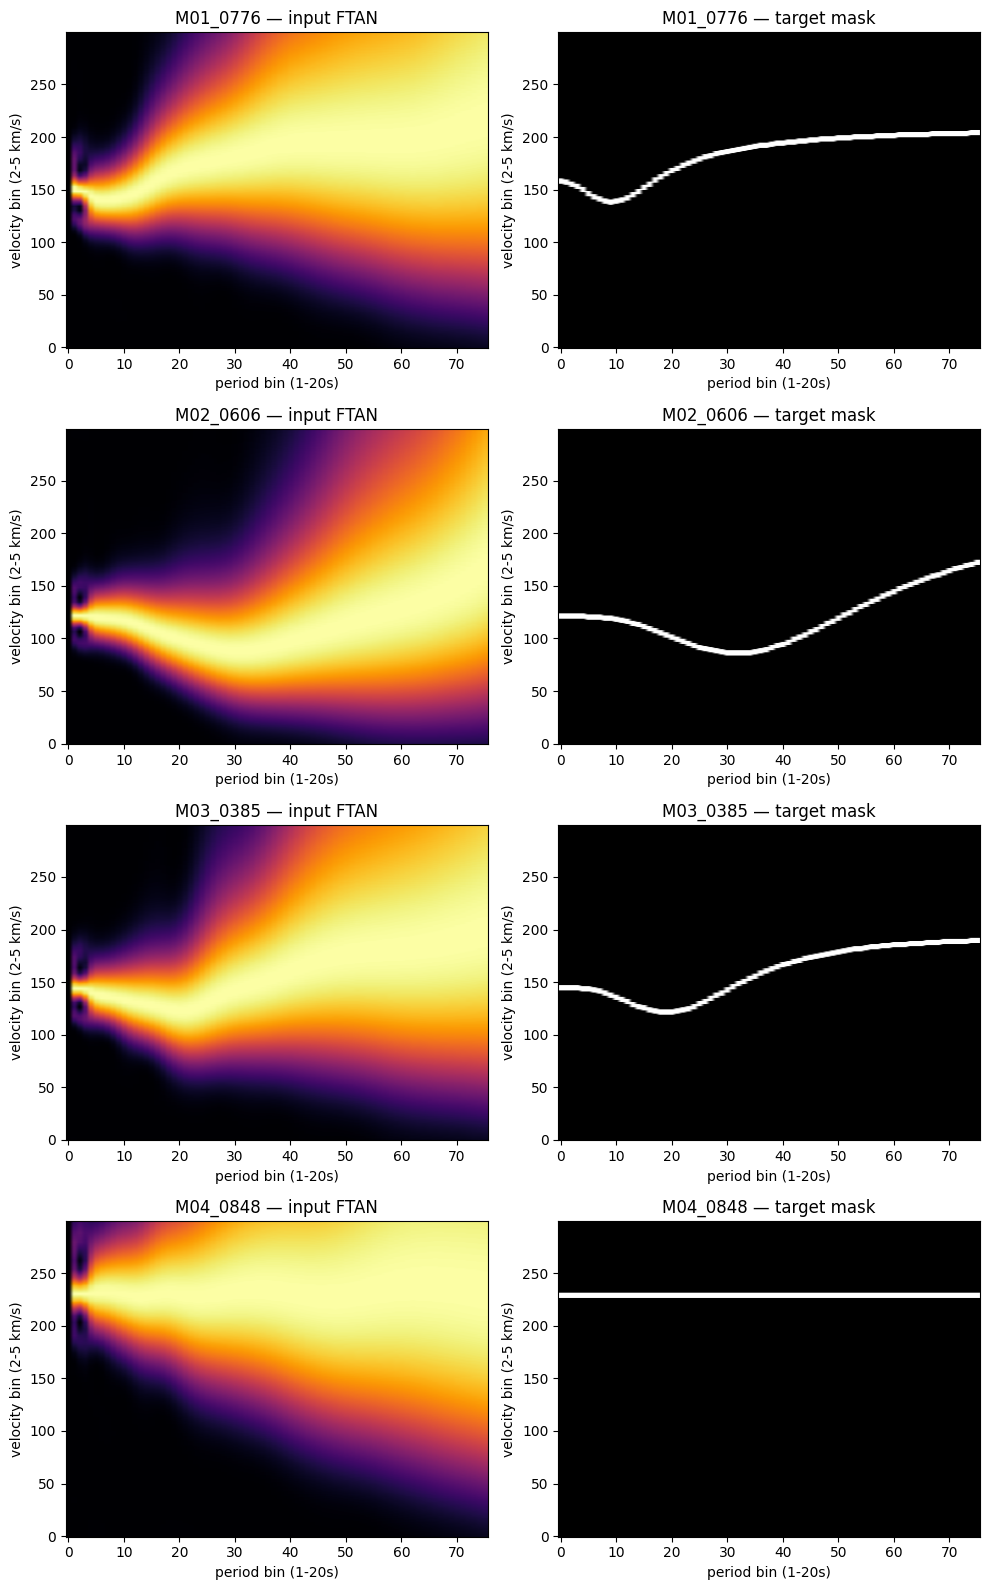

In [5]:
fig, axes = plt.subplots(len(preview), 2, figsize=(10, 4 * len(preview)))
for row, (x, y, meta) in enumerate(preview):
    ax_ftan, ax_mask = axes[row]
    ax_ftan.imshow(x[:76].T, cmap="inferno", aspect="auto", origin="lower")
    ax_ftan.set_title(f"{meta['sim_key']} — input FTAN")
    ax_mask.imshow(y[:76].T, cmap="gray", aspect="auto", origin="lower")
    ax_mask.set_title(f"{meta['sim_key']} — target mask")
    for ax in (ax_ftan, ax_mask):
        ax.set_xlabel("period bin (1-20s)")
        ax.set_ylabel("velocity bin (2-5 km/s)")
plt.tight_layout()
plt.show()


## 6. Family-aware train/val/test split

Split by family (M01-M10) across **both** files at once — verified this session that the
same `Model_ID` shares an identical `velocity_profile` across files, so this is safe.
With only 10 families, the split is necessarily coarse: 7 train / 2 val / 1 test
families (a judgment call — see the stage doc's Open Questions).

In [6]:
train, val, test = splits_mod.family_split(samples, seed=42)
print(f"train: {len(train)} samples, families {sorted({s.family for s in train})}")
print(f"val:   {len(val)} samples, families {sorted({s.family for s in val})}")
print(f"test:  {len(test)} samples, families {sorted({s.family for s in test})}")


train: 14 samples, families ['M01', 'M03', 'M04', 'M05', 'M06', 'M07', 'M08']
val:   4 samples, families ['M02', 'M10']
test:  2 samples, families ['M09']


## 7. Sanity checks (fail loudly, not silently)

In [7]:
for x, y, meta in preview:
    assert x.shape == (80, 300), f"{meta['sim_key']}: bad input shape {x.shape}"
    assert y.shape == (80, 300), f"{meta['sim_key']}: bad target shape {y.shape}"
    assert set(np.unique(y)) <= {0.0, 1.0}, f"{meta['sim_key']}: mask not binary"
    assert np.all(y[76:] == 0) and np.all(x[76:] == 0), f"{meta['sim_key']}: padded rows not zero"
    assert y.sum() > 0, f"{meta['sim_key']}: degenerate all-zero mask"

assert len(train) + len(val) + len(test) == len(samples)
assert not ({s.family for s in train} & {s.family for s in val} & {s.family for s in test})
print("All sanity checks passed.")


All sanity checks passed.


## 8. What to try next

- Change `ftan_grid.MASK_WIDTH` (default 2) and re-run cell 4/5 — see how the mask band
  widens/narrows around the theoretical curve.
- Build a bigger local sample: `python -m src.wavenet_pipeline.03_machine_learning.build_ml_cache
  --h5 <full production files> --out my_cache.h5 --tutorial-sample --n 100 --seed 7`
  (needs the full production HDF5 files, e.g. via SSH to terravibranium).
- Run `validate_ftan.py` on this subset (small — expect noisier stats than the
  200-sample run reported in the stage doc):
  `python -m src.wavenet_pipeline.03_machine_learning.validate_ftan --h5 <path> --n-samples 10 --out qa_out/`
